In [13]:
import pyarrow.dataset as ds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import numpy as np

sns.set_theme(style="whitegrid")


In [14]:
import duckdb
import os
from pathlib import Path

DATASET_ROOT = Path(os.environ.get("DATASET_ROOT", "/Volumes/T5 EVO"))
DATASET_PATH = DATASET_ROOT / "hf" / "merrec"

con = duckdb.connect(database=":memory:")
con.execute("PRAGMA threads=10")



In [15]:
con.execute(f"""
CREATE VIEW merrec AS
SELECT *
FROM read_parquet('{DATASET_PATH}/**/*.parquet');
""")

In [16]:
events_per_user = con.execute("""
SELECT
    user_id,
    COUNT(*) AS event_count
FROM merrec
GROUP BY user_id
""").fetch_arrow_table()  # small: one row per user

event_counts = np.array(events_per_user["event_count"])

plt.figure(figsize=(8, 6))
plt.hist(event_counts, bins=np.logspace(0, np.log10(event_counts.max()), 50))
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Events per user (log)")
plt.ylabel("Number of users (log)")
plt.title("Events per User Distribution")
plt.tight_layout()
plt.show()


RuntimeError: Query interrupted

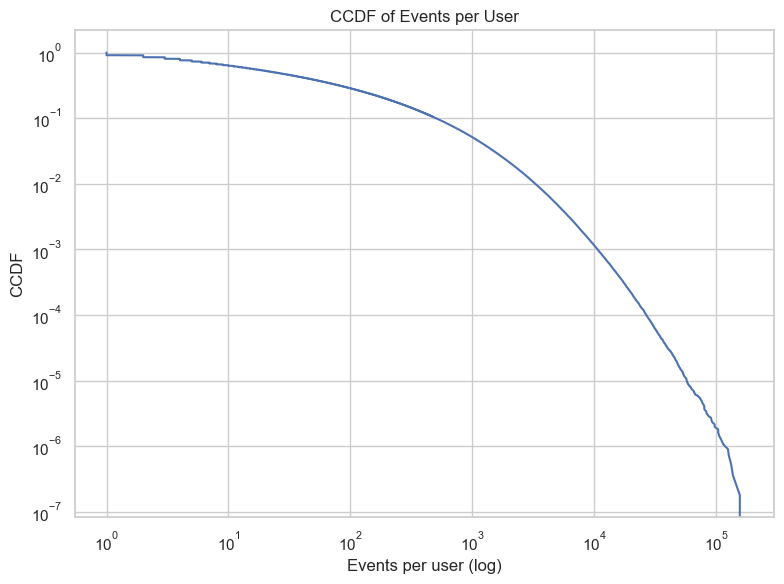

In [ ]:
sorted_counts = np.sort(event_counts)
ccdf = 1.0 - np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

plt.figure(figsize=(8, 6))
plt.plot(sorted_counts, ccdf)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Events per user (log)")
plt.ylabel("CCDF")
plt.title("CCDF of Events per User")
plt.tight_layout()
plt.show()


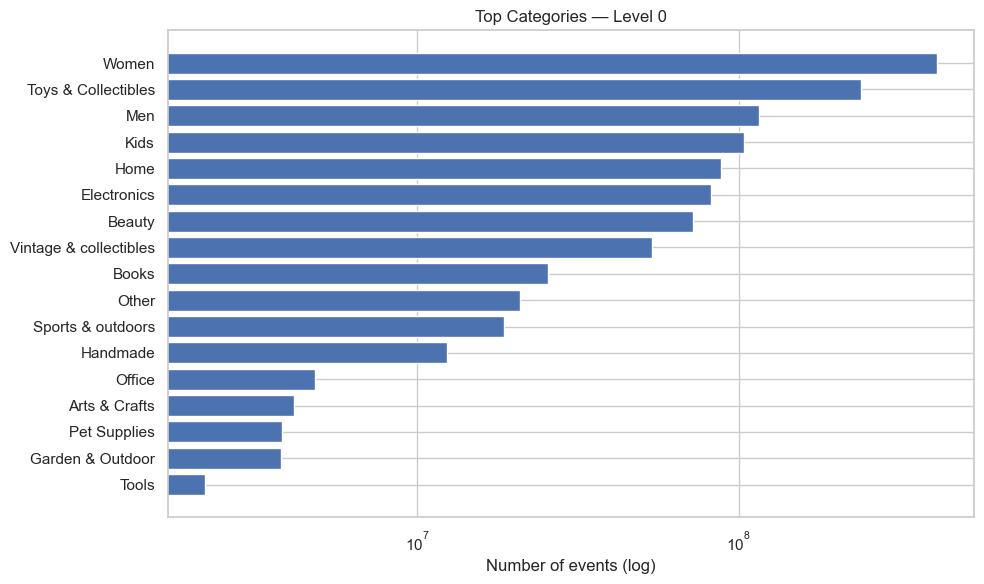

In [ ]:
cat_l0 = con.execute("""
SELECT
    c0_name,
    COUNT(*) AS cnt
FROM merrec
WHERE c0_name IS NOT NULL
GROUP BY c0_name
ORDER BY cnt DESC
LIMIT 20
""").fetch_arrow_table()

labels = np.array(cat_l0["c0_name"])
counts = np.array(cat_l0["cnt"])

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], counts[::-1])
plt.xscale("log")
plt.xlabel("Number of events (log)")
plt.title("Top Categories — Level 0")
plt.tight_layout()
plt.show()


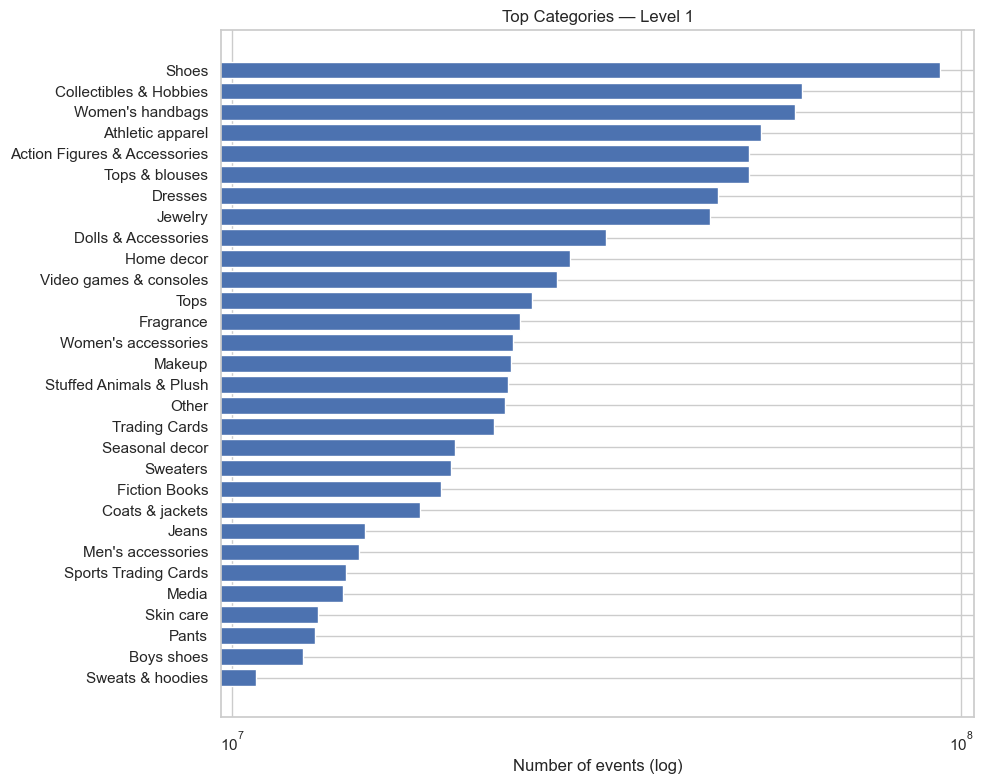

In [ ]:
cat_l1 = con.execute("""
SELECT
    c1_name,
    COUNT(*) AS cnt
FROM merrec
WHERE c1_name IS NOT NULL
GROUP BY c1_name
ORDER BY cnt DESC
LIMIT 30
""").fetch_arrow_table()

labels = np.array(cat_l1["c1_name"])
counts = np.array(cat_l1["cnt"])

plt.figure(figsize=(10, 8))
plt.barh(labels[::-1], counts[::-1])
plt.xscale("log")
plt.xlabel("Number of events (log)")
plt.title("Top Categories — Level 1")
plt.tight_layout()
plt.show()


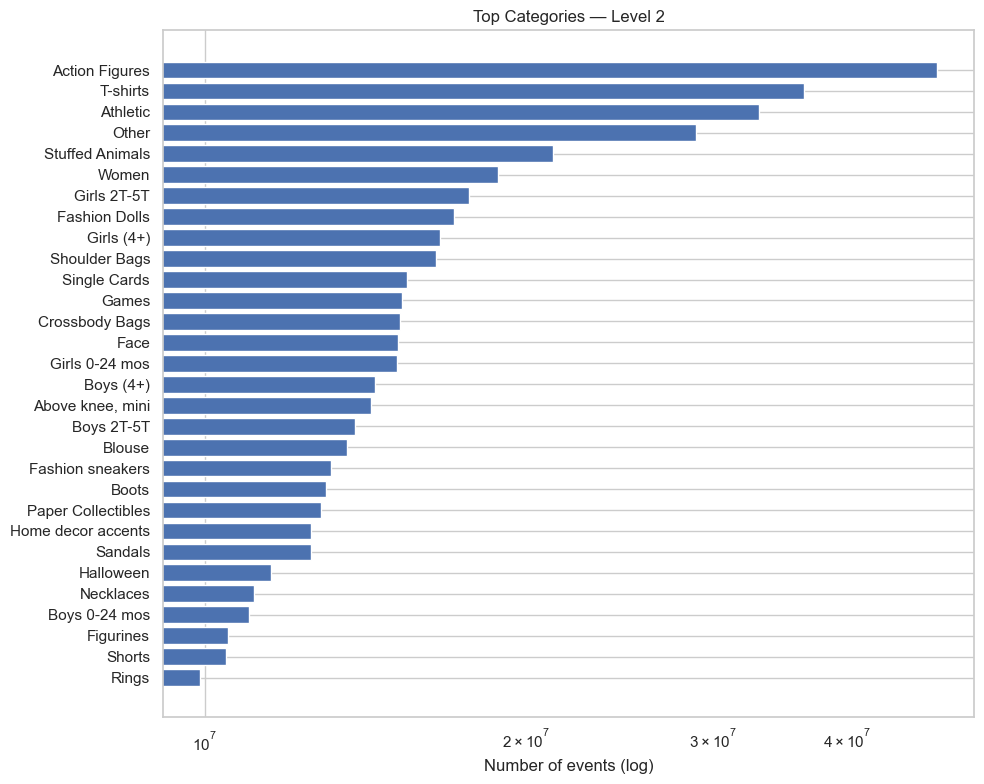

In [ ]:
cat_l2 = con.execute("""
SELECT
    c2_name,
    COUNT(*) AS cnt
FROM merrec
WHERE c2_name IS NOT NULL
GROUP BY c2_name
ORDER BY cnt DESC
LIMIT 30
""").fetch_arrow_table()

labels = np.array(cat_l2["c2_name"])
counts = np.array(cat_l2["cnt"])

plt.figure(figsize=(10, 8))
plt.barh(labels[::-1], counts[::-1])
plt.xscale("log")
plt.xlabel("Number of events (log)")
plt.title("Top Categories — Level 2")
plt.tight_layout()
plt.show()

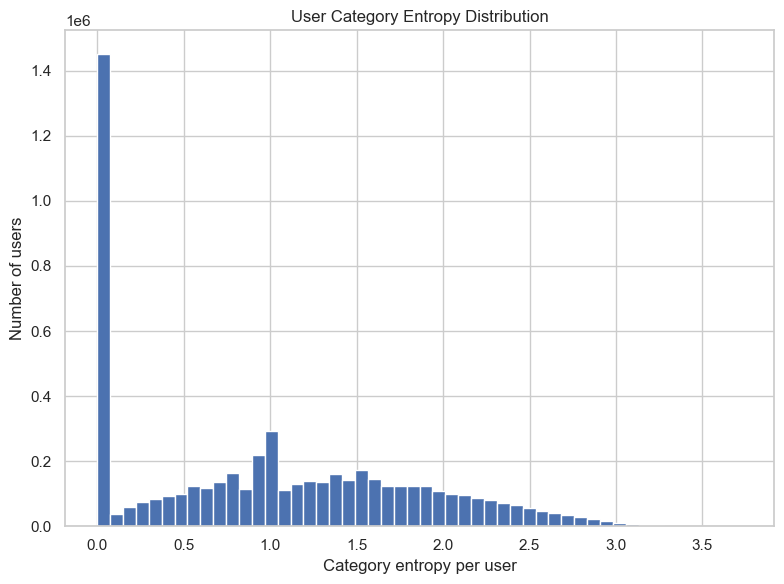

In [ ]:
user_entropy = con.execute("""
WITH user_cat AS (
    SELECT
        user_id,
        c0_name,
        COUNT(*) AS cnt
    FROM merrec
    WHERE c0_name IS NOT NULL
    GROUP BY user_id, c0_name
),
user_totals AS (
    SELECT
        user_id,
        SUM(cnt) AS total
    FROM user_cat
    GROUP BY user_id
)
SELECT
    uc.user_id,
    -SUM((uc.cnt * 1.0 / ut.total) * LOG2(uc.cnt * 1.0 / ut.total)) AS entropy
FROM user_cat uc
JOIN user_totals ut
ON uc.user_id = ut.user_id
GROUP BY uc.user_id
""").fetch_arrow_table()

entropy_vals = np.array(user_entropy["entropy"])

plt.figure(figsize=(8, 6))
plt.hist(entropy_vals, bins=50)
plt.xlabel("Category entropy per user")
plt.ylabel("Number of users")
plt.title("User Category Entropy Distribution")
plt.tight_layout()
plt.show()


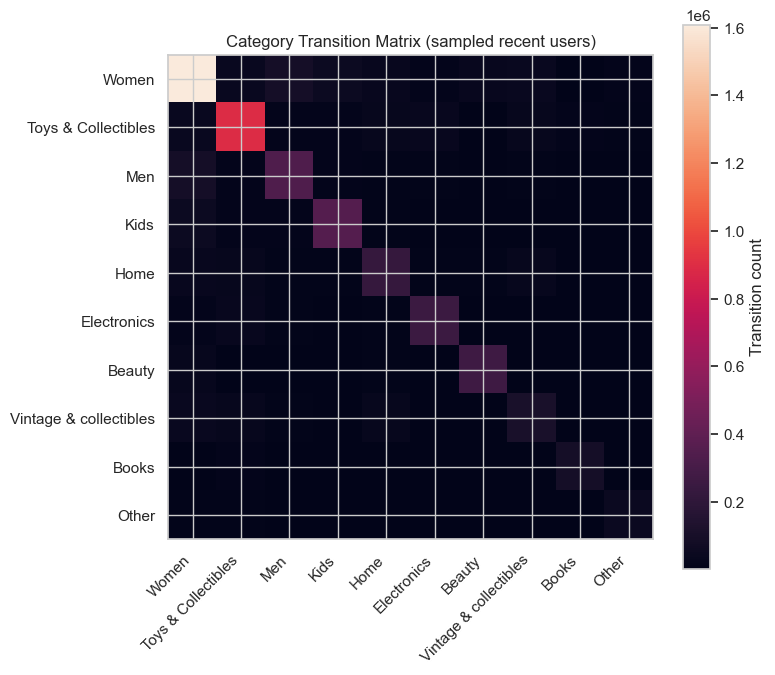

In [ ]:
# Compute category transition matrix entirely in SQL but on a sampled recent subset to avoid spilling to disk
transition = con.execute("""
WITH top AS (
    SELECT c0_name
    FROM (
        SELECT c0_name, COUNT(*) AS cnt
        FROM merrec
        WHERE c0_name IS NOT NULL
        GROUP BY c0_name
        ORDER BY cnt DESC
        LIMIT 10
    )
),
-- Sample a bounded set of users who touched top categories recently
recent_bounds AS (
    SELECT MAX(stime) - INTERVAL '90 days' AS start FROM merrec
),
sampled_users AS (
    SELECT user_id
    FROM merrec, top, recent_bounds
    WHERE merrec.c0_name IN (SELECT c0_name FROM top)
      AND merrec.stime >= recent_bounds.start
    GROUP BY user_id
    ORDER BY RANDOM()
    LIMIT 20000
),
events AS (
    SELECT user_id, stime, c0_name
    FROM merrec
    WHERE user_id IN (SELECT user_id FROM sampled_users)
      AND c0_name IN (SELECT c0_name FROM top)
),
ordered AS (
    SELECT
        user_id,
        stime,
        c0_name,
        LEAD(c0_name) OVER (PARTITION BY user_id ORDER BY stime) AS next_cat
    FROM events
)
SELECT
    c0_name AS from_cat,
    next_cat AS to_cat,
    COUNT(*) AS cnt
FROM ordered
WHERE next_cat IS NOT NULL
GROUP BY c0_name, next_cat
""").df()

# Build matrix in Python from SQL result (small)
if transition.empty:
    print("No transitions found for sampled users.")
else:
    top_cats = con.execute("SELECT c0_name FROM (SELECT c0_name, COUNT(*) AS cnt FROM merrec WHERE c0_name IS NOT NULL GROUP BY c0_name ORDER BY cnt DESC LIMIT 10)").fetchdf()["c0_name"].tolist()
    cat_index = {c: i for i, c in enumerate(top_cats)}
    matrix = np.zeros((len(top_cats), len(top_cats)))
    for _, row in transition.iterrows():
        f = row['from_cat']
        t = row['to_cat']
        if f in cat_index and t in cat_index:
            matrix[cat_index[f], cat_index[t]] = row['cnt']

    plt.figure(figsize=(8, 7))
    plt.imshow(matrix, norm=None)
    plt.xticks(range(len(top_cats)), top_cats, rotation=45, ha='right')
    plt.yticks(range(len(top_cats)), top_cats)
    plt.colorbar(label='Transition count')
    plt.title('Category Transition Matrix (sampled recent users)')
    plt.tight_layout()
    plt.show()


### Event Type Distribution

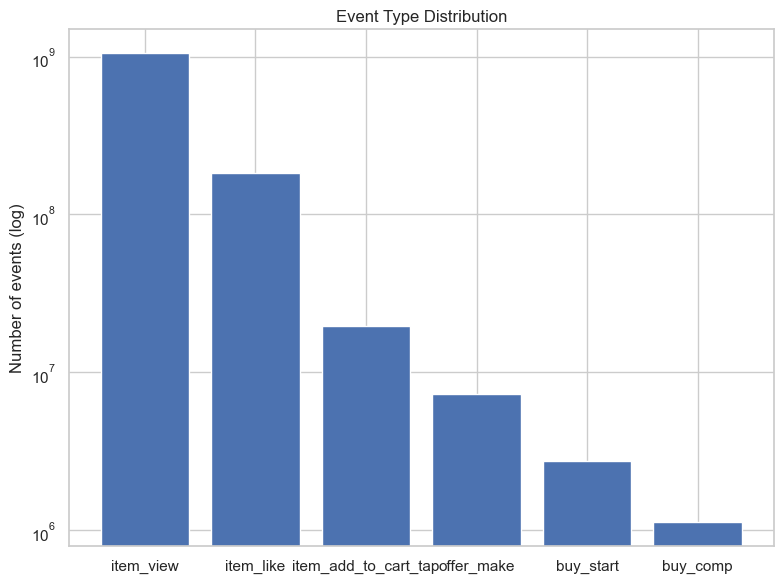

In [ ]:
event_dist = con.execute("""
SELECT
    event_id,
    COUNT(*) AS cnt
FROM merrec
GROUP BY event_id
ORDER BY cnt DESC
""").fetch_arrow_table()

event_labels = event_dist["event_id"].to_pylist()
event_counts = np.array(event_dist["cnt"])

plt.figure(figsize=(8, 6))
plt.bar(event_labels, event_counts)
plt.yscale("log")
plt.ylabel("Number of events (log)")
plt.title("Event Type Distribution")
plt.tight_layout()
plt.show()

### Funnel Counts (View → Like → Cart → Purchase)

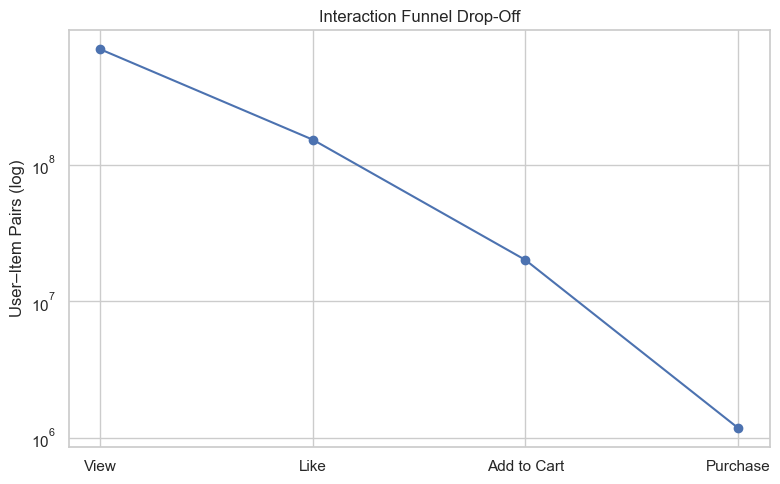

In [ ]:
funnel = con.execute("""
SELECT
    APPROX_COUNT_DISTINCT(CONCAT_WS(',', CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR))) FILTER (WHERE event_id = 'item_view') AS views,
    APPROX_COUNT_DISTINCT(CONCAT_WS(',', CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR))) FILTER (WHERE event_id = 'item_like') AS likes,
    APPROX_COUNT_DISTINCT(CONCAT_WS(',', CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR))) FILTER (WHERE event_id = 'item_add_to_cart_tap') AS carts,
    APPROX_COUNT_DISTINCT(CONCAT_WS(',', CAST(user_id AS VARCHAR), CAST(item_id AS VARCHAR))) FILTER (WHERE event_id = 'buy_comp') AS purchases
FROM merrec
""").fetch_arrow_table()

stages = ["View", "Like", "Add to Cart", "Purchase"]
counts = [
    funnel["views"][0].as_py(),
    funnel["likes"][0].as_py(),
    funnel["carts"][0].as_py(),
    funnel["purchases"][0].as_py(),
]

plt.figure(figsize=(8, 5))
plt.plot(stages, counts, marker="o")
plt.yscale("log")
plt.ylabel("User–Item Pairs (log)")
plt.title("Interaction Funnel Drop-Off")
plt.tight_layout()
plt.show()




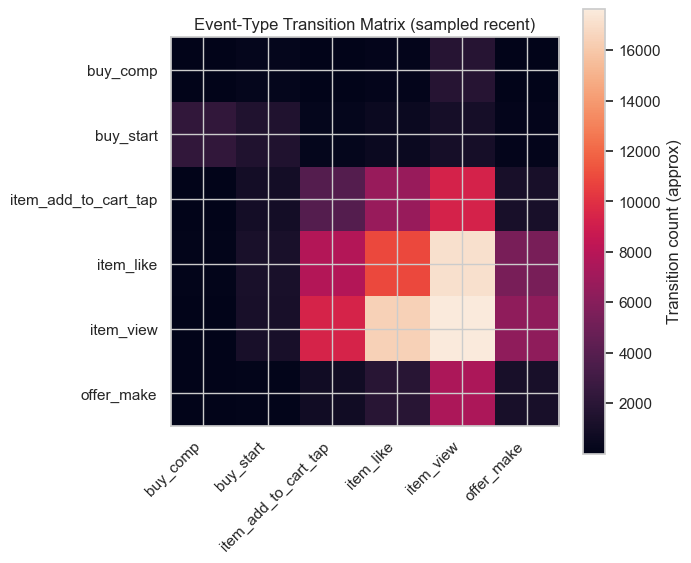

In [ ]:
# Event-Type Transition Matrix (sampled recent events to avoid temp files)

event_transition = con.execute("""
WITH recent_bounds AS (
    SELECT MAX(stime) - INTERVAL '30 days' AS start FROM merrec
),
sampled_users AS (
    SELECT user_id
    FROM merrec, recent_bounds
    WHERE merrec.stime >= recent_bounds.start
    GROUP BY user_id
    ORDER BY RANDOM()
    LIMIT 20000
),
ordered AS (
    SELECT
        user_id,
        stime,
        event_id,
        LEAD(event_id) OVER (
            PARTITION BY user_id ORDER BY stime
        ) AS next_event
    FROM merrec
    WHERE user_id IN (SELECT user_id FROM sampled_users)
)
SELECT
    event_id AS from_event,
    next_event AS to_event,
    APPROX_COUNT_DISTINCT(user_id) AS cnt
FROM ordered
WHERE next_event IS NOT NULL
GROUP BY from_event, to_event
""").fetch_arrow_table()

from_events = event_transition["from_event"].to_pylist()
to_events = event_transition["to_event"].to_pylist()
counts = np.array([x.as_py() for x in event_transition["cnt"]])

unique_events = sorted(set(from_events) | set(to_events))
event_idx = {e: i for i, e in enumerate(unique_events)}

matrix = np.zeros((len(unique_events), len(unique_events)))

for f, t, c in zip(from_events, to_events, counts):
    if f in event_idx and t in event_idx:
        matrix[event_idx[f], event_idx[t]] = c

plt.figure(figsize=(7, 6))
plt.imshow(matrix)
plt.xticks(range(len(unique_events)), unique_events, rotation=45, ha="right")
plt.yticks(range(len(unique_events)), unique_events)
plt.colorbar(label="Transition count (approx)")
plt.title("Event-Type Transition Matrix (sampled recent)")
plt.tight_layout()
plt.show()


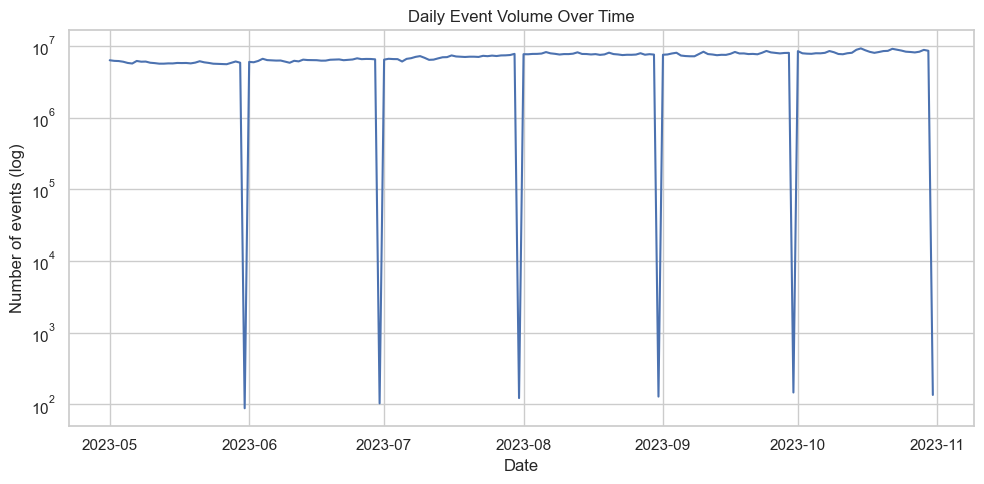

In [ ]:
# =====================================================
# 5.1 Global Event Volume Over Time (Daily)
# =====================================================

daily_events = con.execute("""
SELECT
    DATE(stime) AS day,
    COUNT(*) AS num_events
FROM merrec
GROUP BY day
ORDER BY day
""").fetch_arrow_table()

days = np.array(daily_events["day"])
events = np.array(daily_events["num_events"])

plt.figure(figsize=(10, 5))
plt.plot(days, events)
plt.yscale("log")
plt.xlabel("Date")
plt.ylabel("Number of events (log)")
plt.title("Daily Event Volume Over Time")
plt.tight_layout()
plt.show()

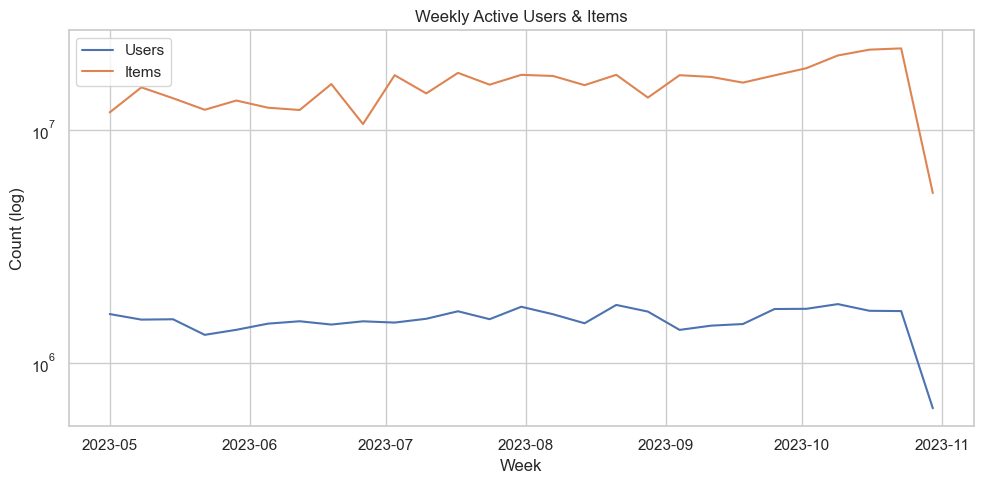

In [ ]:
# =====================================================
# 5.2 Unique Users & Items Over Time (Weekly)
# =====================================================

weekly_activity = con.execute("""
SELECT
    DATE_TRUNC('week', stime) AS week,
    APPROX_COUNT_DISTINCT(user_id) AS users,
    APPROX_COUNT_DISTINCT(item_id) AS items
FROM merrec
GROUP BY week
ORDER BY week
""").fetch_arrow_table()

weeks = np.array(weekly_activity["week"])
users = np.array([x.as_py() for x in weekly_activity["users"]])
items = np.array([x.as_py() for x in weekly_activity["items"]])

plt.figure(figsize=(10, 5))
plt.plot(weeks, users, label="Users")
plt.plot(weeks, items, label="Items")
plt.yscale("log")
plt.xlabel("Week")
plt.ylabel("Count (log)")
plt.title("Weekly Active Users & Items")
plt.legend()
plt.tight_layout()
plt.show()


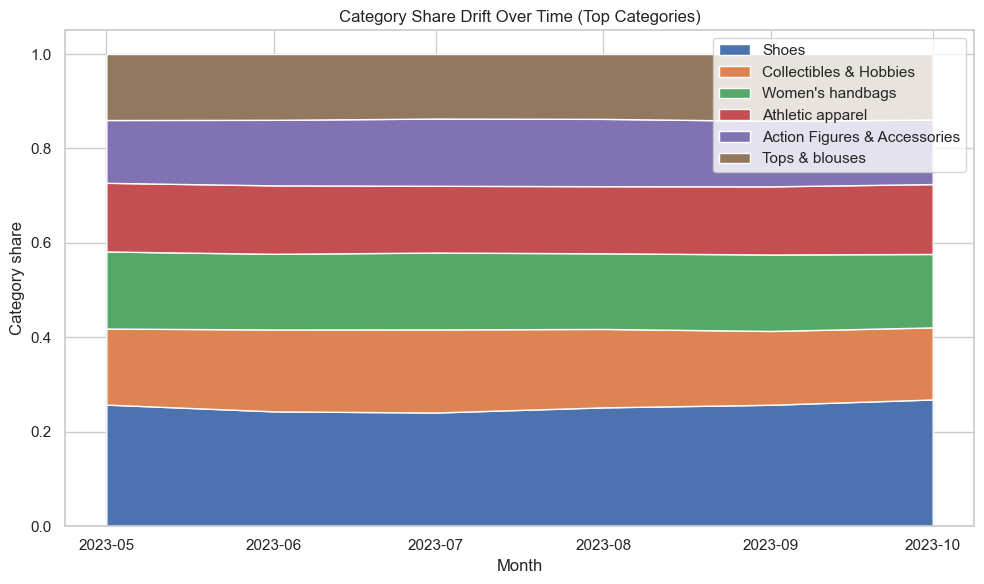

In [ ]:
# =====================================================
# 5.3 Category Share Drift (Top-K Categories, Monthly)
# =====================================================

top_categories = con.execute("""
SELECT c1_name
FROM (
    SELECT c1_name, COUNT(*) AS cnt
    FROM merrec
    WHERE c1_name IS NOT NULL
    GROUP BY c1_name
    ORDER BY cnt DESC
    LIMIT 6
)
""").fetch_arrow_table()

# Build a safely quoted SQL list of top categories (escape single quotes)
top_cats_list = top_categories["c1_name"].to_pylist()
escaped = [c.replace("'", "''") for c in top_cats_list]
top_cats_sql = "(" + ", ".join(f"'{c}'" for c in escaped) + ")"

category_trends = con.execute(f"""
SELECT
    DATE_TRUNC('month', stime) AS month,
    c1_name,
    COUNT(*) AS cnt
FROM merrec
WHERE c1_name IN {top_cats_sql}
GROUP BY month, c1_name
ORDER BY month
""").fetch_arrow_table()

months = np.array(category_trends["month"])
cats = category_trends["c1_name"].to_pylist()
counts = np.array(category_trends["cnt"])

unique_months = np.unique(months)
cat_index = {c: i for i, c in enumerate(top_cats_list)}
matrix = np.zeros((len(unique_months), len(top_cats_list)))

for m, c, v in zip(months, cats, counts):
    i = np.where(unique_months == m)[0][0]
    j = cat_index[c]
    matrix[i, j] += v

# Normalize to shares (per month)
matrix = matrix / matrix.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 6))
plt.stackplot(unique_months, matrix.T, labels=top_cats_list)
plt.xlabel("Month")
plt.ylabel("Category share")
plt.title("Category Share Drift Over Time (Top Categories)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

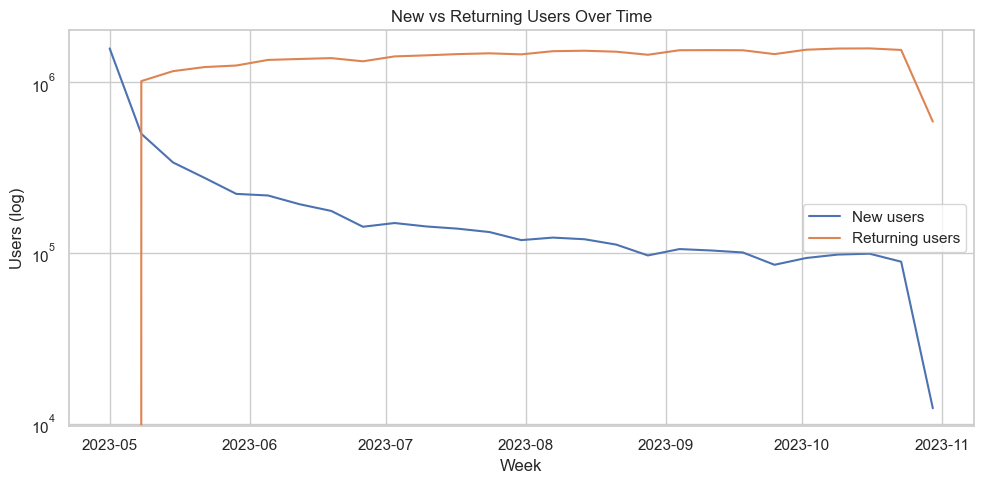

In [ ]:
# =====================================================
# 5.5 New vs Returning Users Over Time (Weekly)
# =====================================================

new_vs_returning = con.execute("""
WITH first_seen AS (
    SELECT
        user_id,
        MIN(DATE_TRUNC('week', stime)) AS first_week
    FROM merrec
    GROUP BY user_id
),
weekly_users AS (
    SELECT
        DATE_TRUNC('week', stime) AS week,
        user_id
    FROM merrec
    GROUP BY week, user_id
)
SELECT
    wu.week,
    COUNT(CASE WHEN wu.week = fs.first_week THEN 1 END) AS new_users,
    COUNT(CASE WHEN wu.week > fs.first_week THEN 1 END) AS returning_users
FROM weekly_users wu
JOIN first_seen fs
ON wu.user_id = fs.user_id
GROUP BY wu.week
ORDER BY wu.week
""").fetch_arrow_table()

weeks = np.array(new_vs_returning["week"])
new_users = np.array(new_vs_returning["new_users"])
returning_users = np.array(new_vs_returning["returning_users"])

plt.figure(figsize=(10, 5))
plt.plot(weeks, new_users, label="New users")
plt.plot(weeks, returning_users, label="Returning users")
plt.yscale("log")
plt.xlabel("Week")
plt.ylabel("Users (log)")
plt.title("New vs Returning Users Over Time")
plt.legend()
plt.tight_layout()
plt.show()

### Columns in the Dataset

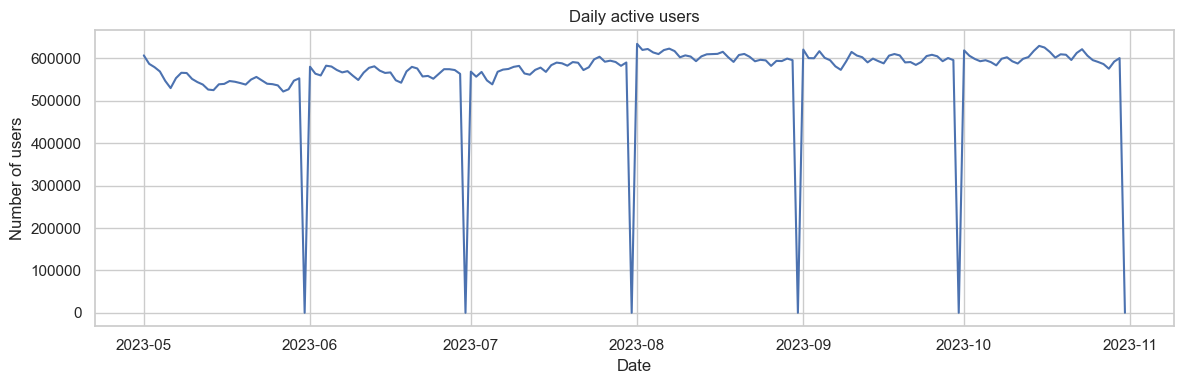

In [ ]:
df = con.execute(
    """
    SELECT
        date_trunc('day', stime) AS d,
        COUNT(DISTINCT user_id) AS users
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY 1
    """,
    [str(DATASET_PATH)],
).df()

df["d"] = pd.to_datetime(df["d"])

plt.figure(figsize=(12, 4))
plt.plot(df["d"], df["users"])
plt.title("Daily active users")
plt.xlabel("Date")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()


### Daily Interactions Volume 

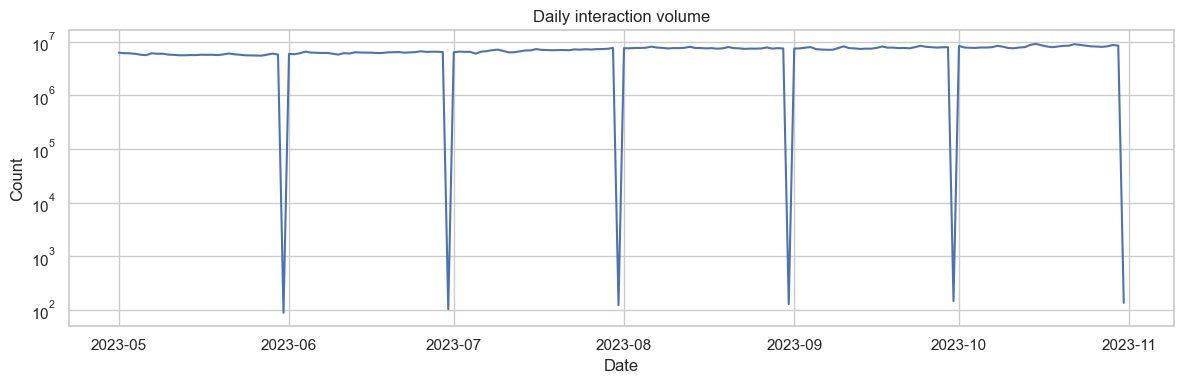

In [ ]:
df = con.execute(
    """
    SELECT date_trunc('day', stime) AS d, COUNT(*) AS c
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY 1
    """,
    [str(DATASET_PATH)],
).df()

df["d"] = pd.to_datetime(df["d"])
s = df.set_index("d")["c"]

plt.figure(figsize=(12, 4))
plt.plot(s.index.to_numpy(), s.to_numpy())
plt.title("Daily interaction volume")
plt.xlabel("Date")
plt.yscale("log")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Users per day (activity breadth)

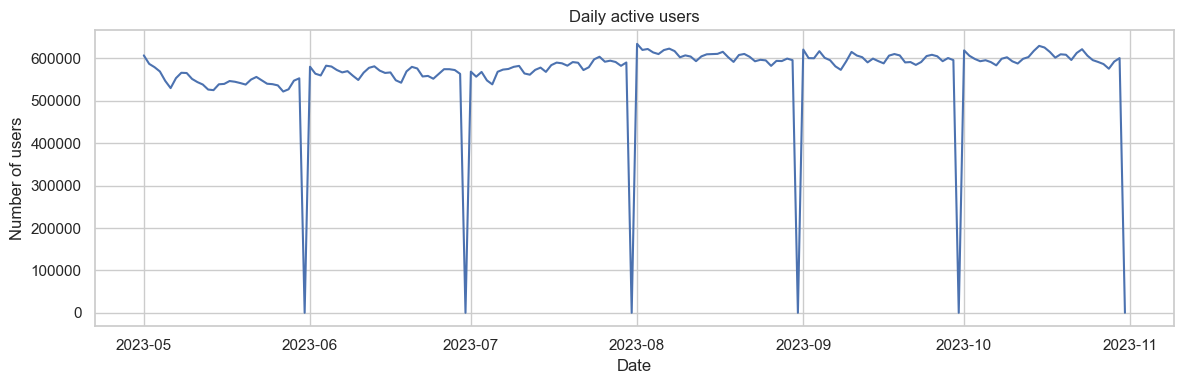

In [ ]:
df = con.execute(
    """
    SELECT
        date_trunc('day', stime) AS d,
        COUNT(DISTINCT user_id) AS users
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY 1
    """,
    [str(DATASET_PATH)],
).df()

df["d"] = pd.to_datetime(df["d"])

plt.figure(figsize=(12, 4))
plt.plot(df["d"], df["users"])
plt.title("Daily active users")
plt.xlabel("Date")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()


### Items per day (catalog dynamics)

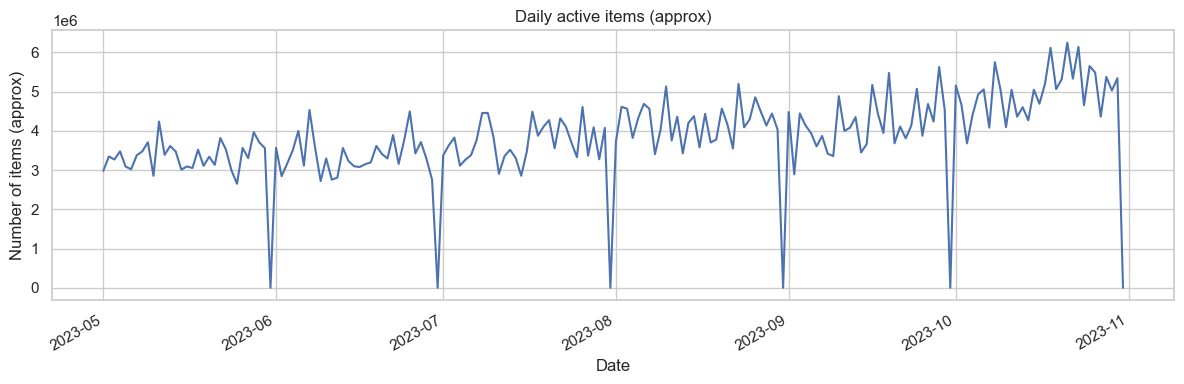

In [ ]:
df = con.execute(
    """
    SELECT
        date_trunc('day', stime) AS d,
        approx_count_distinct(item_id) AS items
    FROM read_parquet(?)
    GROUP BY 1
    ORDER BY 1
    """,
    [str(DATASET_PATH)],
).df()

# ensure datetime and plot safely
df["d"] = pd.to_datetime(df["d"]) 
# approx_count_distinct returns float-like; convert to int
if "items" in df.columns:
    df["items"] = df["items"].astype(int)

plt.figure(figsize=(12, 4))
plt.plot(df["d"].to_numpy(), df["items"].to_numpy())
plt.gcf().autofmt_xdate()
plt.title("Daily active items (approx)")
plt.xlabel("Date")
plt.ylabel("Number of items (approx)")
plt.tight_layout()
plt.show()


### User activity distribution (long-tail)

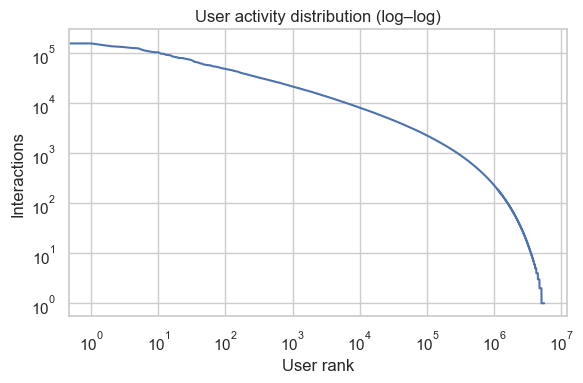

In [ ]:
df = con.execute(
    """
    SELECT
        ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) AS rank,
        COUNT(*) AS c
    FROM read_parquet(?)
    GROUP BY user_id
    ORDER BY rank
    """,
    [str(DATASET_PATH)],
).df()

plt.figure(figsize=(6, 4))
plt.plot(df["c"])
plt.yscale("log")
plt.xscale("log")
plt.title("User activity distribution (log–log)")
plt.xlabel("User rank")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()


### User lifespan (very informative)

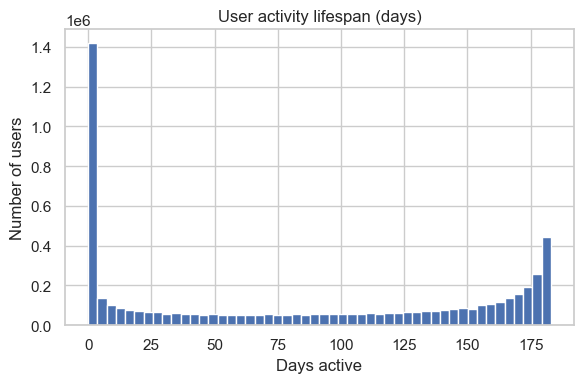

In [ ]:
df = con.execute(
    """
    SELECT
        EXTRACT(EPOCH FROM (MAX(stime) - MIN(stime))) / 86400.0 AS days
    FROM read_parquet(?)
    GROUP BY user_id
    """,
    [str(DATASET_PATH)],
).df()

plt.figure(figsize=(6, 4))
plt.hist(df["days"], bins=50)
plt.title("User activity lifespan (days)")
plt.xlabel("Days active")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()


### Interactions per user vs lifespan

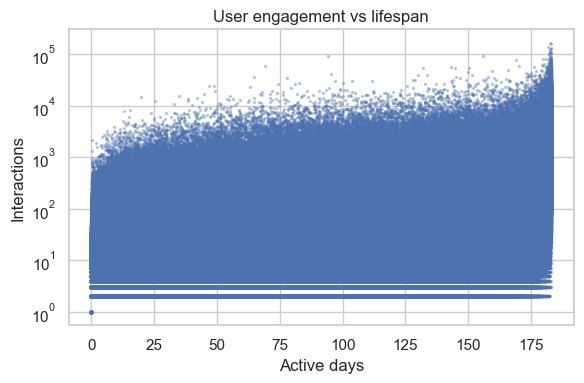

In [ ]:
df = con.execute(
    """
    SELECT
        user_id,
        COUNT(*) AS interactions,
        EXTRACT(EPOCH FROM (MAX(stime) - MIN(stime))) / 86400.0 AS span
    FROM read_parquet(?)
    GROUP BY user_id
    """,
    [str(DATASET_PATH)],
).df()

plt.figure(figsize=(6, 4))
plt.scatter(df["span"], df["interactions"], s=2, alpha=0.3)
plt.yscale("log")
plt.xlabel("Active days")
plt.ylabel("Interactions")
plt.title("User engagement vs lifespan")
plt.tight_layout()
plt.show()


### User behavorial Regimes 

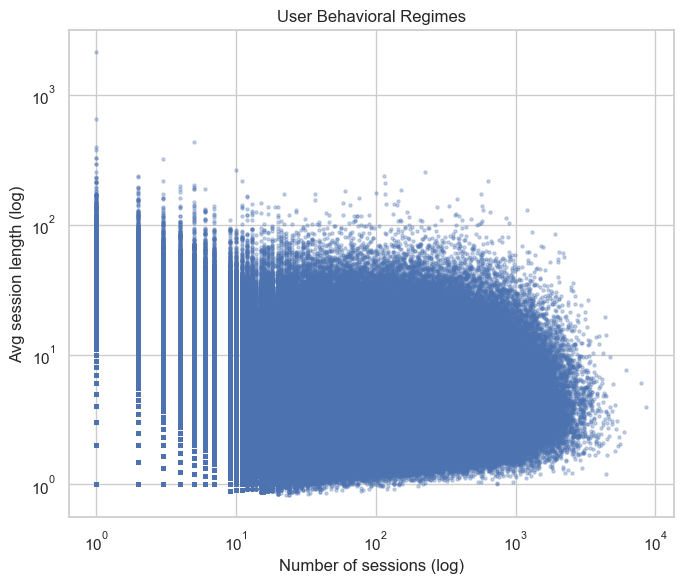

In [ ]:
# User behavioral regimes (memory-efficient SQL using approximations)

user_sessions = con.execute("""
SELECT
    user_id,
    APPROX_COUNT_DISTINCT(session_id) AS num_sessions,
    (COUNT(*) * 1.0) / NULLIF(APPROX_COUNT_DISTINCT(session_id), 0) AS avg_session_len
FROM merrec
GROUP BY user_id
""").fetch_arrow_table()

x = np.array([v.as_py() for v in user_sessions["num_sessions"]])
y = np.array([v.as_py() for v in user_sessions["avg_session_len"]])

plt.figure(figsize=(7,6))
plt.scatter(x, y, s=5, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of sessions (log)")
plt.ylabel("Avg session length (log)")
plt.title("User Behavioral Regimes")
plt.tight_layout()
plt.show()


### User Preference Entropy (Category)

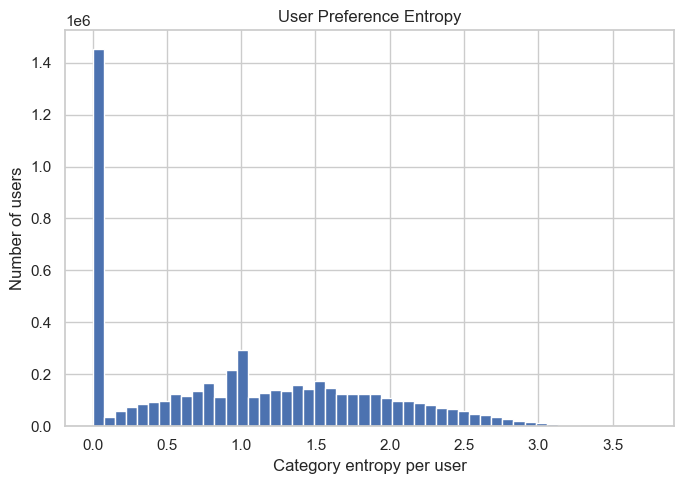

In [ ]:
entropy = con.execute("""
WITH user_cat AS (
    SELECT
        user_id,
        c0_name,
        COUNT(*) AS cnt
    FROM merrec
    GROUP BY user_id, c0_name
),
totals AS (
    SELECT user_id, SUM(cnt) AS total
    FROM user_cat
    GROUP BY user_id
)
SELECT
    uc.user_id,
    -SUM((uc.cnt * 1.0 / t.total) *
         LOG2(uc.cnt * 1.0 / t.total)) AS entropy
FROM user_cat uc
JOIN totals t ON uc.user_id = t.user_id
GROUP BY uc.user_id
""").fetch_arrow_table()

vals = np.array(entropy["entropy"])

plt.figure(figsize=(7,5))
plt.hist(vals, bins=50)
plt.xlabel("Category entropy per user")
plt.ylabel("Number of users")
plt.title("User Preference Entropy")
plt.tight_layout()
plt.show()


### Item Attention Half-Life

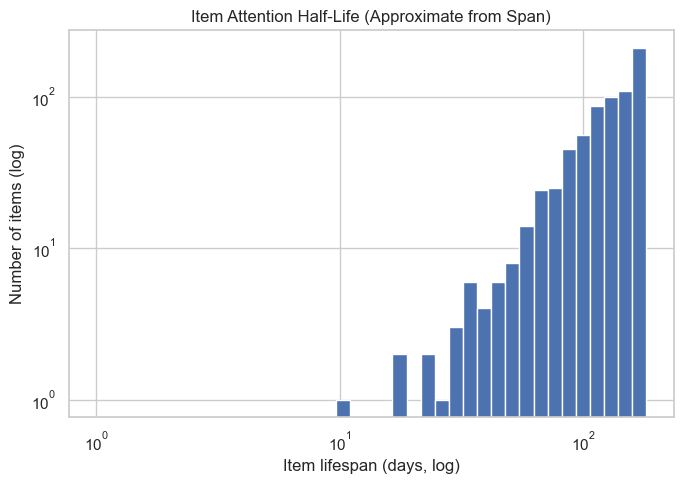

In [ ]:
half_life = con.execute("""
WITH top_items AS (
    SELECT item_id
    FROM merrec
    WHERE price IS NOT NULL
    GROUP BY item_id
    ORDER BY COUNT(*) DESC
    LIMIT 1000
),
item_spans AS (
    SELECT
        ti.item_id,
        DATEDIFF('day', MIN(DATE(m.stime)), MAX(DATE(m.stime))) AS span_days
    FROM merrec m
    JOIN top_items ti USING(item_id)
    GROUP BY ti.item_id
)
SELECT
    item_id,
    CASE WHEN span_days = 0 THEN 1 ELSE span_days END AS half_life_days
FROM item_spans
""").fetch_arrow_table()

hl = np.array([v.as_py() if v.as_py() is not None else 1 for v in half_life["half_life_days"]])

plt.figure(figsize=(7,5))
if len(hl) > 0:
    plt.hist(hl, bins=np.logspace(0, np.log10(max(hl.max(), 2)), 40))
    plt.xscale("log")
    plt.yscale("log")
plt.xlabel("Item lifespan (days, log)")
plt.ylabel("Number of items (log)")
plt.title("Item Attention Half-Life (Approximate from Span)")
plt.tight_layout()
plt.show()

In [19]:
df = con.execute(
    f"""
    SELECT COUNT(*) AS total_records FROM read_parquet('{DATASET_PATH}/**/*.parquet')
    """
).df()

print("Total records in dataset:")
print(df)
print("\n" + "="*50)
print(f"Schema info from the view:")
schema = con.execute("DESCRIBE merrec").df()
print(schema)

Total records in dataset:
   total_records
0     1268092738

Schema info from the view:
            column_name column_type null   key default extra
0               user_id      BIGINT  YES  None    None  None
1                 stime   TIMESTAMP  YES  None    None  None
2            session_id     VARCHAR  YES  None    None  None
3           sequence_id     VARCHAR  YES  None    None  None
4       sequence_length      BIGINT  YES  None    None  None
5              event_id     VARCHAR  YES  None    None  None
6               item_id      BIGINT  YES  None    None  None
7            product_id     VARCHAR  YES  None    None  None
8                  name     VARCHAR  YES  None    None  None
9                 price      DOUBLE  YES  None    None  None
10              c0_name     VARCHAR  YES  None    None  None
11                c0_id      BIGINT  YES  None    None  None
12              c1_name     VARCHAR  YES  None    None  None
13                c1_id      BIGINT  YES  None    None  No